# Enviroment Variables

In [750]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
from torch.nn import Sigmoid
from sklearn.datasets import make_moons, make_blobs

RELATIVE_ERROR = 1e-12

# Utils

In [751]:
class Visualization :

    @staticmethod
    def make_scatter(x, y, c):
        plt.figure()

        plt.scatter(x, y, c=c)

        plt.title("Diagrama de Dipersión")
        plt.xlabel("Eje X")
        plt.ylabel("Eje Y")

        plt.tight_layout()

    @staticmethod
    def make_error_plot(history_error, title : str):
        plt.figure()

        plt.plot(history_error)
        plt.title(f"{title} - Gráfica de Error")
        plt.xlabel("Iteración")
        plt.ylabel("Error")

    @staticmethod
    def make_scatter_with_line(x, y, c, y_line, title : str):
        plt.figure()
        plt.scatter(x,y,c=c)

        plt.plot(x,y_line)

        plt.title(f"Diagrama de Disperción {title} con la superficie de decisión")
        plt.xlabel("Eje X")
        plt.ylabel("Eje Y")

    @staticmethod
    def show():
        plt.show()

visualization = Visualization()

class Table:
    """! The Table class
    Defines the functions used to generate, update and show a pandas dataframe
    """
    def __init__(self, data: pd.DataFrame, names : list[str]):
        """! The Table class initializer
        @param data The panda data frame
        @param names The names used to define the columns in the table

        @return An instance of the Table class initialized with a dataframe with the given columns names
        """

        # The dataframe of the table
        self.data = data

        # Initialize all the columns with the given names
        for name in names:
            self.data[name] = []

    def add(self, row : int, column : str, value):
        """! Add a value in a specific column of the table
        @param row Row in the table
        @param column Column in the table
        @param value Value to add in the table
        """

        # Rounds float values for consistency
        if isinstance(value, float):
            value = round(value, 6)

        # Inserts or updates the value in the table
        self.data.loc[row, column] = value

    def show(self):
        """! Show the table
        """

        # Show the dataframe
        print(self.data)

    def generate_latex(self, index : bool, name : str):
        self.data.to_latex(f"{name}.tex", index=index)

# Perceptron Algorithm

In [752]:
class Perceptron:

    def forward(self, X : torch.Tensro, w : torch.Tensor):
        return torch.sign(X @ w)

    def gradient(self, X : torch.Tensor, w : torch.Tensor, t : torch.Tensor):
        perceptron_criteria = (X @ w) * t
        mask = (perceptron_criteria <= 0).squeeze()

        U = X[mask]
        t_U = t[mask]

        return (U * t_U).sum(dim=0).view(-1, 1)

    def error(self, X : torch.Tensor, w : torch.Tensor, t : torch.Tensor):
        return (t - self.forward(X, w)).abs().mean()

    def accuracy(self, X : torch.Tensor, w : torch.Tensor, t : torch.Tensor):
        return (self.forward(X, w) == t).float().mean()

    def train(self, X : torch.Tensor, w : torch.Tensor, t : torch.Tensor, iterations : int, alpha : float):
        history_error = []
        for i in range(iterations):
            history_error.append(self.error(X,w,t).item())
            delta = self.gradient(X, w, t)
            w = w + alpha * delta

        return w, history_error

# Logistic Regression

In [753]:
class LogisticRegression:

    def __init__(self):
        self.sigmoid = Sigmoid()

    def forward(self, X : torch.Tensor, w : torch.Tensor):
        return self.sigmoid(X @ w)

    def gradient(self, X :torch.Tensor, w : torch.Tensor, t : torch.Tensor):
        diff = (X * (t - self.forward(X, w))).sum(dim=0)
        return diff.view(-1, 1) / X.shape[0]

    def medium_absolute_error(self, X : torch.Tensor, w : torch.Tensor, t : torch.Tensor):
        return (t - self.forward(X, w)).abs().mean()

    def accuracy(self, X : torch.Tensor, w : torch.Tensor, t : torch.Tensor):
        return (self.forward(X, w) == t).float().mean()

    def train(self, X : torch.Tensor, w : torch.Tensor, t : torch.Tensor, iterations : int, alpha : float):
        history_error = []
        for i in range(iterations):
            history_error.append(self.medium_absolute_error(X, w, t).item())
            delta = self.gradient(X, w, t)
            w = w + alpha * delta

        return w, history_error

# Unit tests: Forward

## Test 1 - Forward

In [754]:
def logistic_regression_forward_test_1():
    # objetivos
    X = torch.tensor([
        [1.0, 35.0, 50],
        [1.0, 40.0, 53],
        [1.0, 25.0, 80],
        [1.0, 28.0, 73]
    ])

    w = torch.tensor([
        [0.3],
        [0.2],
        [0.25]
    ])

    expected_product = torch.tensor([
            [19.8],
            [21.55],
            [25.3],
            [24.15]
    ])

    sigmoid = Sigmoid()
    logistic_regression = LogisticRegression()

    expected_result = sigmoid(expected_product)
    result = logistic_regression.forward(X, w)

    assert (expected_result-result).abs().max().item() < RELATIVE_ERROR

logistic_regression_forward_test_1()

# Generate Dataset

In [755]:
class DatasetGenerator:

    @staticmethod
    def generate_nonlinearly_separable(seed):
        X,Y = make_moons(noise=0.15, random_state=seed)
        X_tensor = torch.tensor(X, dtype=torch.float32)
        Y_tensor = torch.tensor(Y, dtype=torch.float32)
        return X_tensor, Y_tensor

    @staticmethod
    def generate_linearly_separable(seed):
        X, Y = make_blobs(centers=2, random_state=seed, cluster_std=0.1)
        X_tensor = torch.tensor(X, dtype=torch.float32)
        Y_tensor = torch.tensor(Y, dtype=torch.float32)
        return X_tensor, Y_tensor

    @staticmethod
    def split(X : torch.Tensor, Y : torch.Tensor, ratio = 0.7):
        separated_X = X.split(int(X.shape[0]*ratio))
        separated_Y = Y.split(int(Y.shape[0]*ratio))
        return [separated_X[0], separated_Y[0]], [separated_X[1], separated_Y[1]]

# Logistic Regression Analysis

In [756]:
class LogisticRegressionAnalysis:

    def __init__(self):
        self.model = LogisticRegression()
        self.iterations = 100
        self.alpha = 1
        self.seed = 777

    def train(self, name : str, training_data: list[torch.Tensor]):
        data, labels = training_data
        N = data.shape[0]
        data = torch.cat((torch.ones(N, 1), data), dim=1)
        w, history_error = self.model.train(data, torch.rand(3).view(-1, 1) , labels.view(-1, 1), self.iterations, self.alpha)
        visualization.make_error_plot(history_error,name)
        return w, history_error

    def testData(self, name: str, test_data: list[torch.Tensor], w : torch.Tensor):
        M, t = test_data
        #t_estimated= self.model.forward(M, w).round()
        y_line = -(w[0] + w[1] * M[:,0]) / w[2]
        visualization.make_scatter_with_line(M[:,0], M[:,1],t, y_line, name)
        visualization.show()

    def make_table(self, table : Table, separable_errors : list[float], nonseparable_errors : list[float]):
        for i in range(self.iterations):
            table.add(i,"Linealmente separable", separable_errors[i])
            table.add(i,"No linealmente separable", nonseparable_errors[i])
            table.add(i, "Diferencia Absoluta", abs(separable_errors[i] - nonseparable_errors[i]))
            table.add(i, "Menor error", "Linealmente separable" if separable_errors[i] < nonseparable_errors[i] else "No linealmente separable" )

    def run(self):
        error_table = Table(pd.DataFrame(),["Linealmente separable", "No linealmente separable", "Diferencia Absoluta"])

        separable_points, separable_classification = DatasetGenerator.generate_linearly_separable(self.seed)
        separable_training_data, separable_testing_data = DatasetGenerator.split(separable_points,separable_classification)
        separable_w, separable_errors = self.train("Linealmente separable", separable_training_data)

        nonseparable_points, nonseparable_classification = DatasetGenerator.generate_nonlinearly_separable(self.seed)
        nonseparable_training_data, nonseparable_testing_data = DatasetGenerator.split(nonseparable_points,nonseparable_classification)
        nonseparable_w, nonseparable_errors = self.train("No linealmente separable", nonseparable_training_data)

        self.make_table(error_table, separable_errors, nonseparable_errors)

        self.testData("Linealmente separable", separable_testing_data, separable_w)
        self.testData("No linealmente separable", nonseparable_testing_data, nonseparable_w)

        error_table.show()


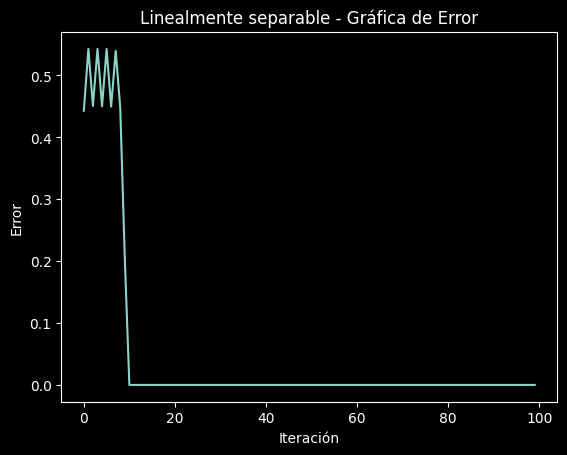

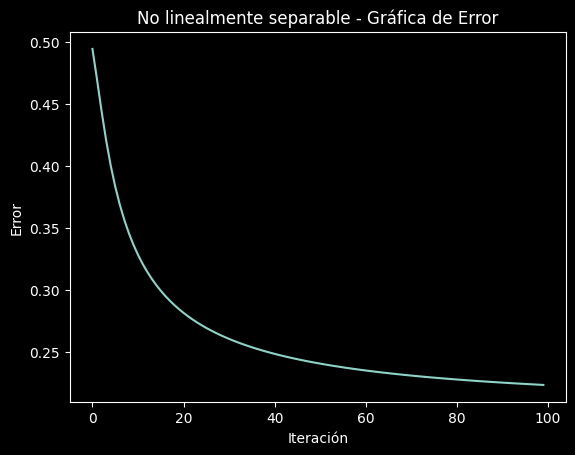

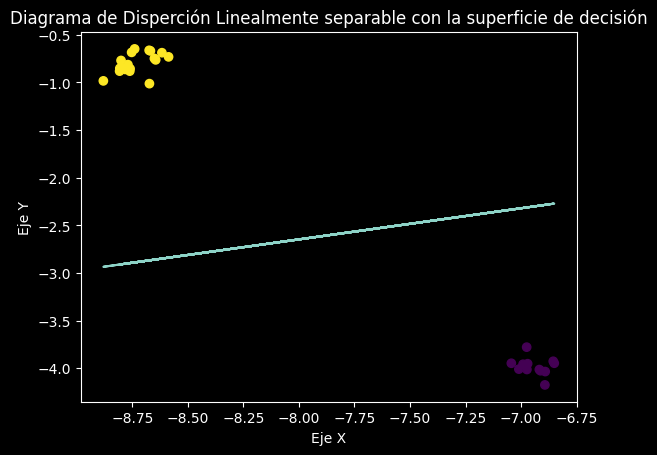

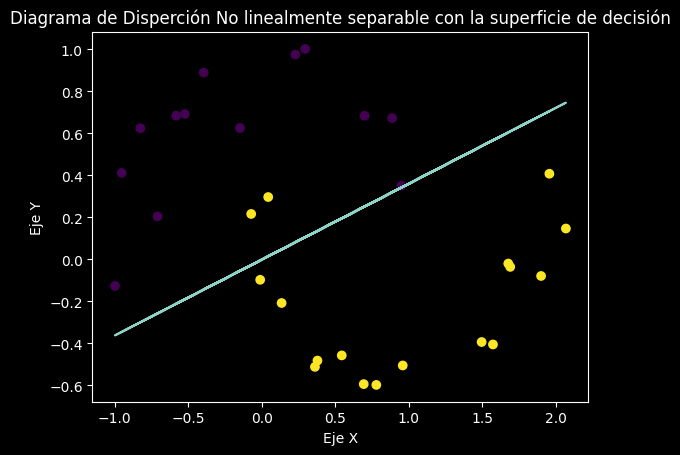

    Linealmente separable  No linealmente separable  Diferencia Absoluta  \
0                0.442956                  0.494058             0.051102   
1                0.542857                  0.469573             0.073285   
2                0.450739                  0.444049             0.006690   
3                0.542857                  0.420619             0.122238   
4                0.450191                  0.400398             0.049793   
..                    ...                       ...                  ...   
95               0.000001                  0.224439             0.224438   
96               0.000001                  0.224237             0.224236   
97               0.000001                  0.224039             0.224038   
98               0.000001                  0.223845             0.223844   
99               0.000001                  0.223654             0.223653   

                 Menor error  
0      Linealmente separable  
1   No linealmente separa

In [757]:
logistic_regression_analysis = LogisticRegressionAnalysis()
logistic_regression_analysis.run()

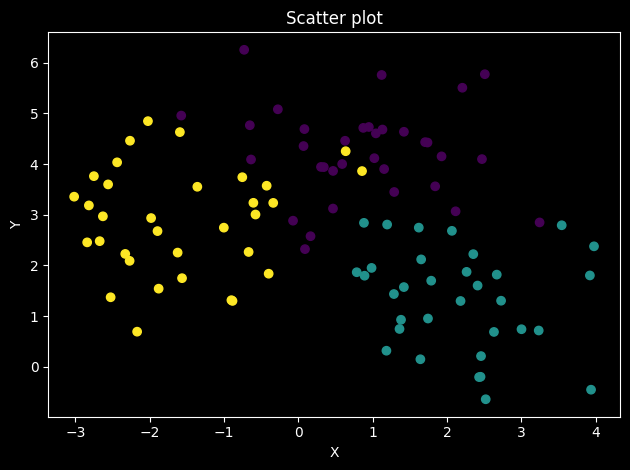

In [98]:
dataset_generator = DatasetGenerator()

# X,Y = dataset_generator.generate_nonlinearly_separable()
X, Y = dataset_generator.generate_linearly_separable()

visualization.make_scatter(X[:,0], X[:,1], Y)
visualization.show()